# Extracting KB

In [3]:
%pip install langchain langgraph langchain-community ollama pydantic scikit-learn pandas matplotlib seaborn numpy 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import json
from typing import TypedDict, Dict, Any
from langgraph.graph import StateGraph, END
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from typing import TypedDict, Dict, Any, List
from pydantic import BaseModel, Field
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, END
from langchain_core.output_parsers import JsonOutputParser



KB_PATH = "./input/KB.md"
PROMPTS_PATH = "./prompts/prompts.json"
ollama_model = "llama3.2"
ollama_model_temperature = 0

# Helper function
def load_json(path: str) -> Dict:
    """Load JSON from file."""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Langgraph setup

In [5]:
from pydantic import BaseModel, Field
from typing import List

# --- 1. DEFINE STRICT PYDANTIC SCHEMAS (UPDATED TO MATCH IMAGE) ---

class CompanyNorthStar(BaseModel):
    inferred_north_star: str = Field(description="The primary inferred North Star metric")
    justification: str = Field(description="The justification for choosing this metric")
    measurable_proxy: str = Field(description="The measurable proxy for the North Star")

class HookTaxonomy(BaseModel):
    hook_name: str
    description: str

class AllowedToneHookMatrix(BaseModel):
    allowed_tones: List[str]
    disallowed_tones: List[str]
    hook_taxonomy: List[HookTaxonomy] = Field(description="Taxonomy of behavioral hooks")

class FeatureMapping(BaseModel):
    feature_name: str
    lifecycle_stage: str = Field(description="The specific lifecycle stage this feature targets")
    outcome_mapping: str = Field(description="The desired outcome mapping for this feature")

class FeatureGoalMap(BaseModel):
    features: List[FeatureMapping]

# --- 2. HARDCODED PROMPTS & SCHEMA MAPPING ---

PROMPTS = {
    "company_north_star": {
        "system": "You are a product analytics expert. Extract the North Star metric details based on the provided Knowledge Base.",
        "user": "Extract the inferred north star metric, its justification, and a measurable proxy from the following KB:\n\nKB:\n{kb}",
        "schema": CompanyNorthStar
    },
    "allowed_tone_hook_matrix": {
        "system": "You are a behavioral design analyst. Extract tone rules and hook taxonomy based on the provided Knowledge Base.",
        "user": "Extract allowed tones, disallowed tones, and a complete hook taxonomy from the following KB:\n\nKB:\n{kb}",
        "schema": AllowedToneHookMatrix
    },
    "feature_goal_map": {
        "system": "You are a product goal alignment specialist. Extract goal mappings for the provided features based on the Knowledge Base.",
        "user": "For EACH of the following features, map it to a specific user lifecycle stage and its intended outcome mapping.\n\nFeatures to map:\n{features}\n\nUse this KB context to inform mappings:\n{kb}",
        "schema": FeatureGoalMap
    }
}

# --- 3. HARDCODED FEATURES (Extracted from CSV) ---
all_columns = [
    "user_id", "lifecycle_stage", "days_since_signup", "age_band", "region", 
    "sessions_last_7d", "exercises_completed_7d", "streak_current", "coins_balance", 
    "feature_ai_tutor_used", "feature_leaderboard_viewed", "feature_progress_checked", 
    "preferred_hour", "notif_open_rate_30d", "motivation_score", "gamification_propensity", 
    "ai_tutor_propensity", "leaderboard_propensity", "activation_score", "dominant_propensity", 
    "activation_level", "segment_id", "segment_name"
]
exclude = {'user_id', 'segment_id', 'segment_name', 'lifecycle_stage', 'activation_level', 'dominant_propensity'}
filtered_columns = [col for col in all_columns if col not in exclude]

FEATURES_STRING = "\n".join([f"{i+1}. {col}" for i, col in enumerate(filtered_columns)])


# --- 4. LANGGRAPH SETUP ---
class KBState(TypedDict):
    kb_text: str
    prompts: Dict[str, Any]
    outputs: Dict[str, Any]
    prompts_used: Dict[str, Any]

llm = ChatOllama(model=ollama_model, temperature=ollama_model_temperature, format="json")
def save_json(path: str, data: Dict):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

def run_llm_with_schema(system_prompt: str, user_prompt: str, schema: BaseModel):
    # Initialize the parser with your specific Pydantic model
    parser = JsonOutputParser(pydantic_object=schema)
    
    # Get the strict formatting instructions generated by Pydantic
    format_instructions = parser.get_format_instructions()
    
    # Inject those instructions into the system prompt
    full_system_prompt = f"{system_prompt}\n\n{format_instructions}"
    
    # Invoke the LLM
    res = llm.invoke([
        SystemMessage(content=full_system_prompt), 
        HumanMessage(content=user_prompt)
    ])
    
    try:
        # The parser automatically validates the JSON string against your Pydantic class
        parsed_data = parser.parse(res.content)
        return parsed_data
    except Exception as e:
        print(f"Validation Error: {e}\nRaw Output: {res.content}")
        return {"error": "LLM failed Pydantic validation.", "raw": res.content}
    
def load_inputs(state: KBState):
    if os.path.exists(KB_PATH):
        with open(KB_PATH, "r", encoding="utf-8") as f:
            state["kb_text"] = f.read()
    else:
        state["kb_text"] = "Dummy knowledge base text."
        
    state["prompts"] = PROMPTS
    state["outputs"] = {}
    state["prompts_used"] = {}
    return state

def run_extraction(key: str):
    def node(state: KBState):
        prompt_block = state["prompts"][key]
        user_prompt = prompt_block["user"].replace("{kb}", state["kb_text"])
        
        if key == "feature_goal_map":
            user_prompt = user_prompt.replace("{features}", FEATURES_STRING)
        
        result = run_llm_with_schema(prompt_block["system"], user_prompt, prompt_block["schema"])
        
        state["outputs"][key] = result
        state["prompts_used"][key] = {"system": prompt_block["system"], "user": user_prompt}
        return state
    return node

def save_outputs(state: KBState):
    for key, value in state["outputs"].items():
        save_json(f"./output/{key}.json", value)
        save_json(f"../iteration_0_before_learning/{key}.json", value)
    return state


# --- 5. BUILD AND EXECUTE GRAPH ---
builder = StateGraph(KBState)
builder.add_node("load", load_inputs)

prompt_keys = list(PROMPTS.keys())
prev_node = "load"

for key in prompt_keys:
    current_node = f"extract_{key}"
    builder.add_node(current_node, run_extraction(key))
    builder.add_edge(prev_node, current_node)
    prev_node = current_node

builder.add_node("save", save_outputs)
builder.add_edge(prev_node, "save")
builder.add_edge("save", END)
builder.set_entry_point("load")

graph = builder.compile()

if __name__ == "__main__":
    print("Starting extraction pipeline with updated Pydantic schemas...")
    final_state = graph.invoke({"kb_text": "", "prompts": {}, "outputs": {}, "prompts_used": {}})
    print("Pipeline complete. Check the output folders.")

Starting extraction pipeline with updated Pydantic schemas...
Pipeline complete. Check the output folders.


# Missing data handeling 

In [44]:
encoded_user_csv_path = "./input/users.csv"
df = pd.read_csv(encoded_user_csv_path)

numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

df.to_csv("./output/users_imputed.csv", index=False)

# Generating Propensity and Activeness scores

In [32]:
df = pd.read_csv("./output/users_imputed.csv")

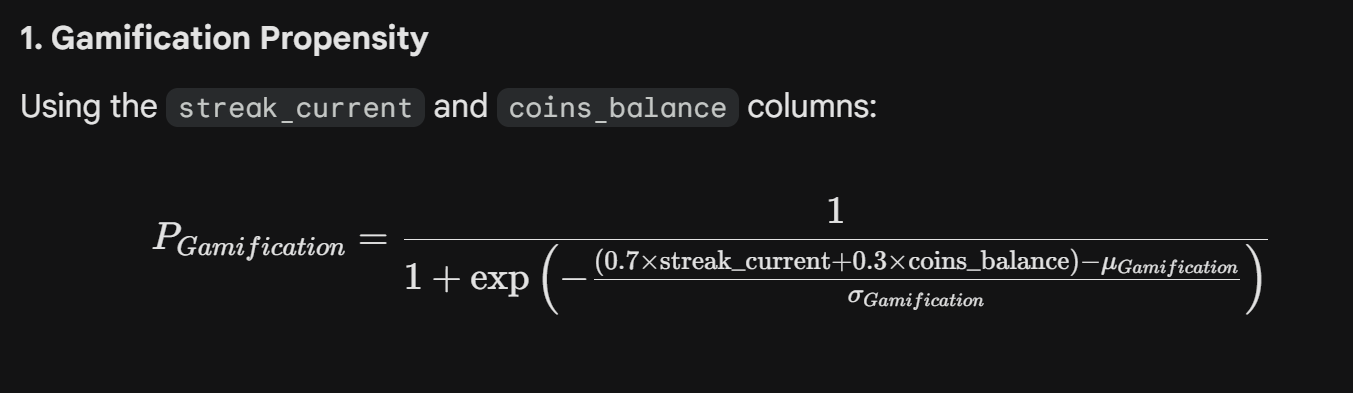

In [33]:
gamification_score = 0.7 * df['streak_current'] + 0.3 * df['coins_balance']
mu = gamification_score.mean()
sigma = gamification_score.std()
df['gamification_propensity'] = 1 / (1 + np.exp(-(gamification_score - mu) / sigma))
df.head(1)

,user_id,lifecycle_stage,days_since_signup,age_band,region,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,preferred_hour,notif_open_rate_30d,motivation_score,gamification_propensity
0,US_1,paid,119,25-34,tier2,5,16,22,453.0,False,False,True,7,0.304,0.65,0.845197


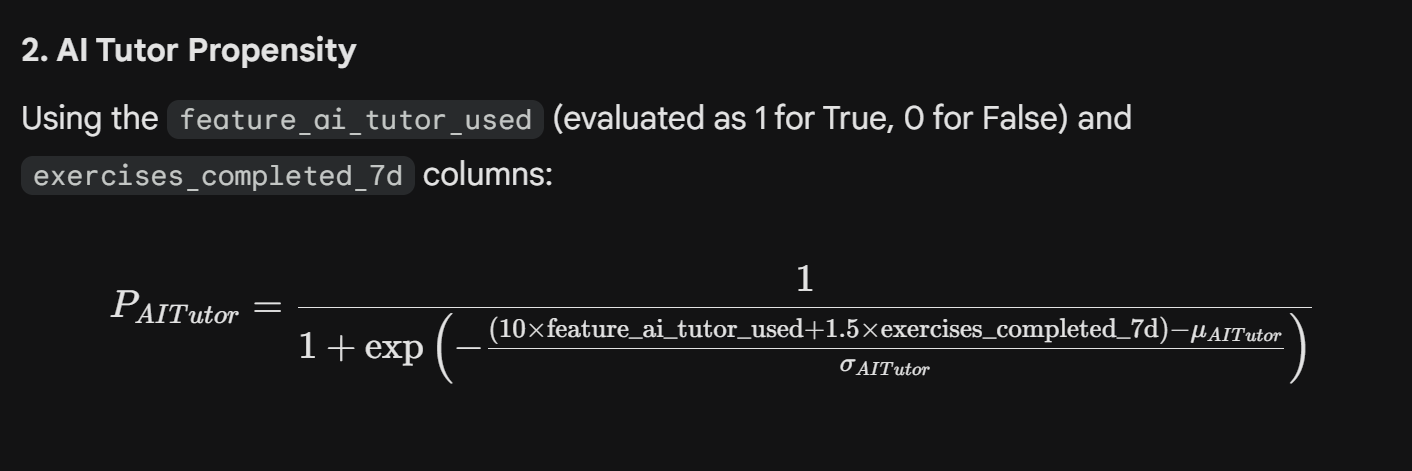

In [34]:
ai_tutor_score = 10 * df['feature_ai_tutor_used'] + 1.5 * df['exercises_completed_7d']
mu = ai_tutor_score.mean()
sigma = ai_tutor_score.std()
df['ai_tutor_propensity'] = 1 / (1 + np.exp(-(ai_tutor_score - mu) / sigma))
df.head(1)

,user_id,lifecycle_stage,days_since_signup,age_band,region,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,preferred_hour,notif_open_rate_30d,motivation_score,gamification_propensity,ai_tutor_propensity
0,US_1,paid,119,25-34,tier2,5,16,22,453.0,False,False,True,7,0.304,0.65,0.845197,0.736033


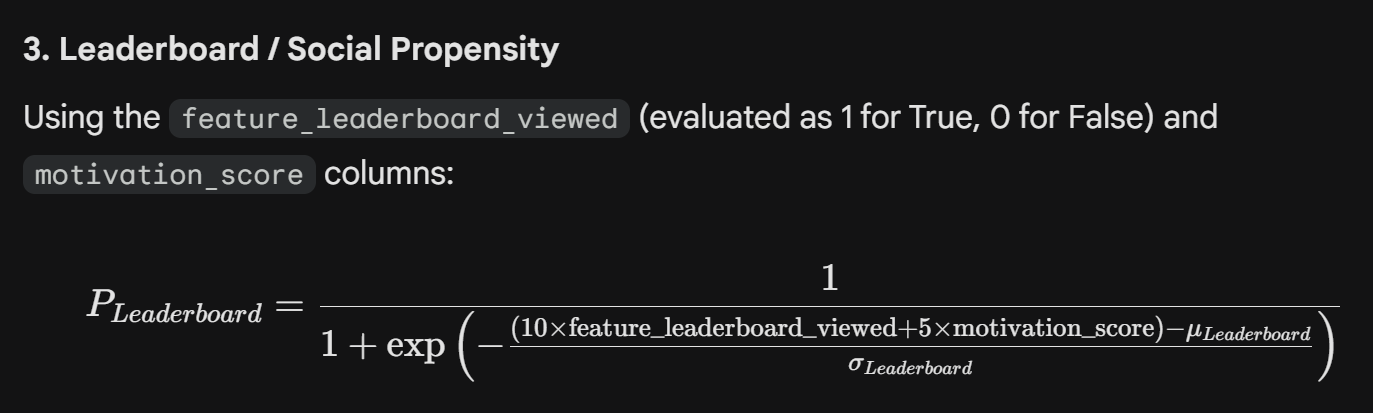

In [35]:
leaderboard_score = 10 * df['feature_leaderboard_viewed'] + 5 * df['motivation_score']
mu = leaderboard_score.mean()
sigma = leaderboard_score.std()
df['leaderboard_propensity'] = 1 / (1 + np.exp(-(leaderboard_score - mu) / sigma))

df.head(1)

,user_id,lifecycle_stage,days_since_signup,age_band,region,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,preferred_hour,notif_open_rate_30d,motivation_score,gamification_propensity,ai_tutor_propensity,leaderboard_propensity
0,US_1,paid,119,25-34,tier2,5,16,22,453.0,False,False,True,7,0.304,0.65,0.845197,0.736033,0.269036


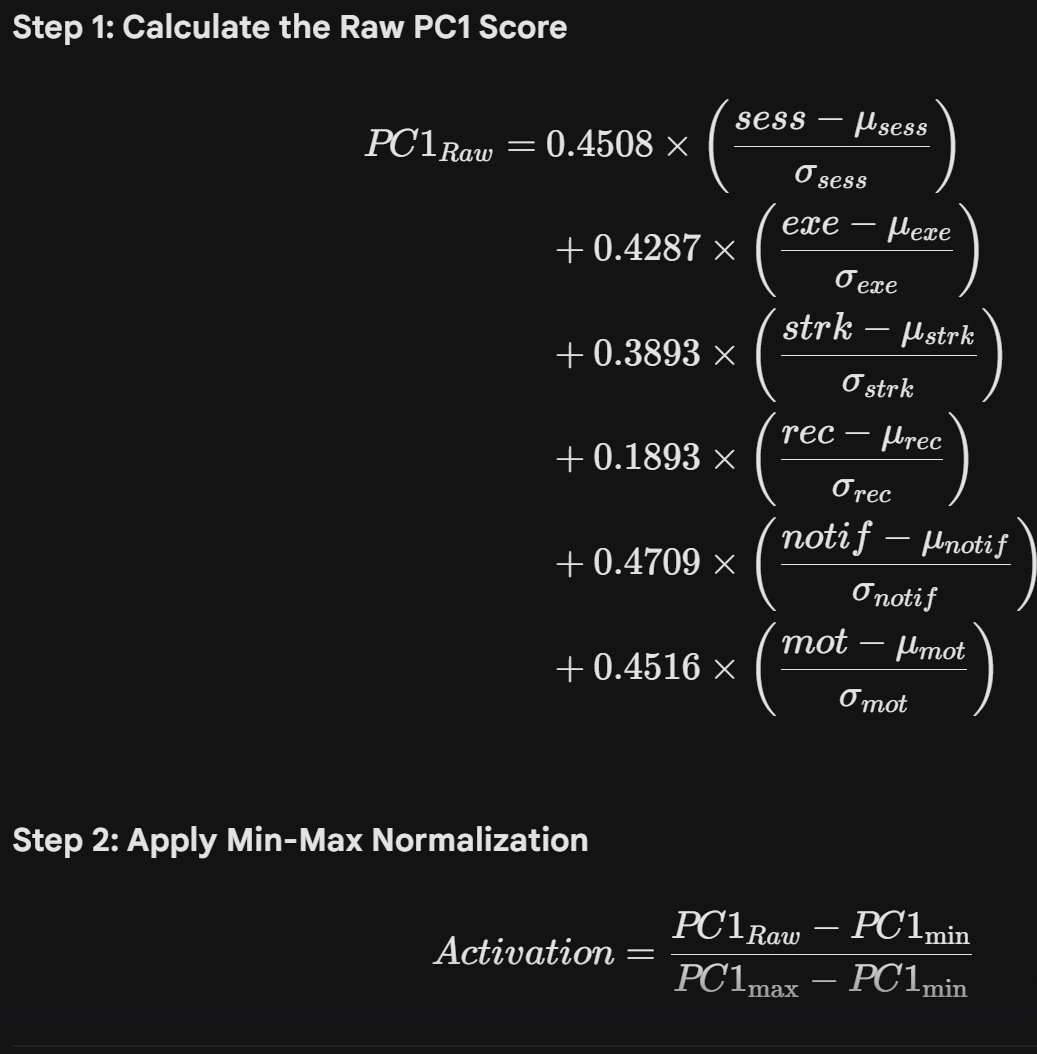

In [36]:
from sklearn.decomposition import PCA

cols = ['sessions_last_7d', 'exercises_completed_7d', 'streak_current', 'notif_open_rate_30d', 'motivation_score']
standardized = pd.DataFrame()
for col in cols:
    standardized[col] = (df[col] - df[col].mean()) / df[col].std()

pca = PCA(n_components=1)
pca.fit(standardized)
weights = {col: pca.components_[0][i] for i, col in enumerate(cols)}

pc1_raw = sum(weights[col] * standardized[col] for col in cols)
pc1_min = pc1_raw.min()
pc1_max = pc1_raw.max()
df['activation_score'] = (pc1_raw - pc1_min) / (pc1_max - pc1_min)

df.head(1)

,user_id,lifecycle_stage,days_since_signup,age_band,region,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,preferred_hour,notif_open_rate_30d,motivation_score,gamification_propensity,ai_tutor_propensity,leaderboard_propensity,activation_score
0,US_1,paid,119,25-34,tier2,5,16,22,453.0,False,False,True,7,0.304,0.65,0.845197,0.736033,0.269036,0.676695


In [37]:
df.to_csv("./output/users_propensity_generated.csv", index=False)

# Segmenting users 

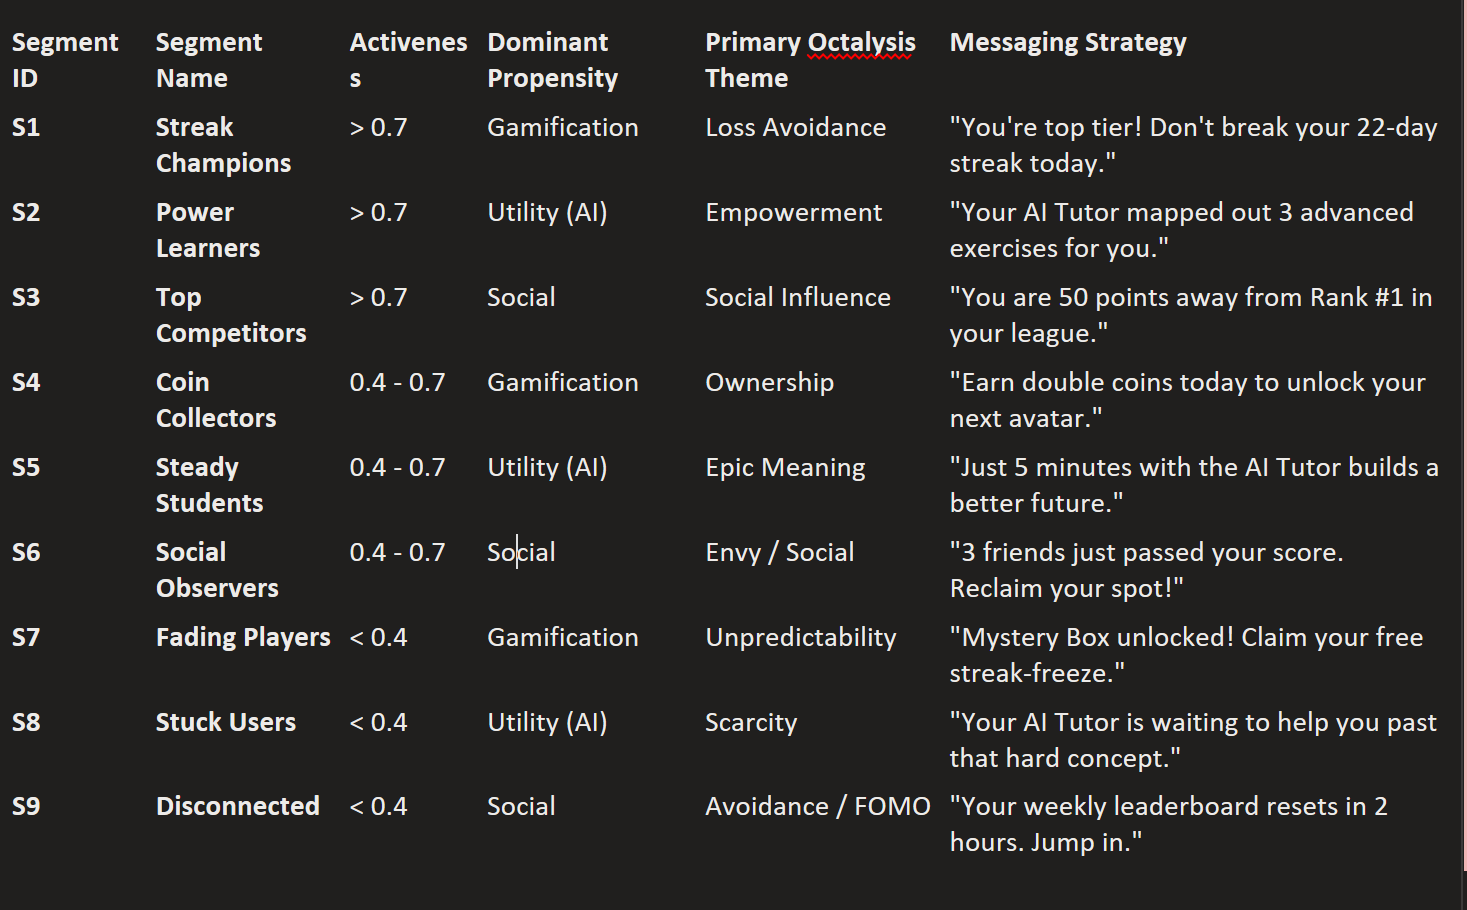

In [38]:
df = pd.read_csv("./output/users_propensity_generated.csv")

df['dominant_propensity'] = df[['gamification_propensity', 'ai_tutor_propensity', 'leaderboard_propensity']].idxmax(axis=1)
df['dominant_propensity'] = df['dominant_propensity'].str.replace('_propensity', '')

def get_activation_level(score):
    if score > 0.7:
        return 'High'
    elif score >= 0.4:
        return 'Medium'
    else:
        return 'Low'

df['activation_level'] = df['activation_score'].apply(get_activation_level)

segment_map = {
    ('gamification', 'High'): ('S1', 'Streak Champions'),
    ('ai_tutor', 'High'): ('S2', 'Power Learners'),
    ('leaderboard', 'High'): ('S3', 'Top Competitors'),
    ('gamification', 'Medium'): ('S4', 'Coin Collectors'),
    ('ai_tutor', 'Medium'): ('S5', 'Steady Students'),
    ('leaderboard', 'Medium'): ('S6', 'Social Observers'),
    ('gamification', 'Low'): ('S7', 'Fading Players'),
    ('ai_tutor', 'Low'): ('S8', 'Stuck Users'),
    ('leaderboard', 'Low'): ('S9', 'Disconnected'),
}

df[['segment_id', 'segment_name']] = df.apply(
    lambda row: pd.Series(segment_map[(row['dominant_propensity'], row['activation_level'])]),
    axis=1
)

df.to_csv("./output/users_segmented.csv", index=False)

# Assigning Goals , Sub-Goals for ech segment * lifecycle stage

In [58]:
# Generate Segment × Lifecycle Stage Goals (36 Combinations)

# Load feature goals and user segments
df_segments = pd.read_csv("./output/users_segmented.csv")
feature_goals = load_json("./output/feature_goal.json")

# Map lifecycle stages to contextual modifiers
lifecycle_context = {
    "trial": {
        "description": "Early Stage - Building Habits",
        "goal_modifier": "rapid adoption & habit formation",
        "focus": "Quick wins and onboarding",
    },
    "paid": {
        "description": "Engaged - Maximizing Value",
        "goal_modifier": "deepening engagement & retention",
        "focus": "Sustained usage and progression",
    },
    "churned": {
        "description": "At-Risk - Re-activation Needed",
        "goal_modifier": "re-engagement & recovering lost habits",
        "focus": "Breaking inactivity cycle",
    },
    "inactive": {
        "description": "Dormant - Win-Back Campaign",
        "goal_modifier": "compelling return value proposition",
        "focus": "Removing friction to return",
    },
}

# Build feature goal mapping by propensity type
feature_goal_map = {}
for feature in feature_goals["features"]:
    propensity_type = feature["feature_name"].replace("_propensity", "")
    feature_goal_map[propensity_type] = {
        "primary_goal": feature["primary_goal"],
        "sub_goals": feature["sub_goals"],
        "progression_goals": feature["day_on_day_progression_goals"],
    }

# Get unique segment and lifecycle combinations
segments = sorted(df_segments[['segment_id', 'segment_name', 'dominant_propensity', 'activation_level']].drop_duplicates()['segment_id'].tolist())
lifecycle_stages = sorted(df_segments['lifecycle_stage'].unique().tolist())

# Ensure exactly 4 lifecycle stages (trial, paid, churned, inactive)
expected_stages = ["trial", "paid", "churned", "inactive"]
available_stages = [s for s in expected_stages if s in lifecycle_stages]
if len(available_stages) < 4:
    available_stages = lifecycle_stages + [s for s in expected_stages if s not in lifecycle_stages]
available_stages = available_stages[:4]

print(f"Segments: {segments}")
print(f"Lifecycle Stages: {available_stages}")
print(f"Total Combinations: {len(segments)} segments × {len(available_stages)} stages = {len(segments) * len(available_stages)}")

# Generate 36 combinations
segment_lifecycle_goals = {
    "combinations": [],
    "metadata": {
        "total_segments": len(segments),
        "total_lifecycle_stages": len(available_stages),
        "total_combinations": len(segments) * len(available_stages),
        "generated_at": pd.Timestamp.now().isoformat(),
    }
}

for segment_id in segments:
    segment_info = df_segments[df_segments['segment_id'] == segment_id].iloc[0]
    segment_name = segment_info['segment_name']
    dominant_propensity = segment_info['dominant_propensity']
    activation_level = segment_info['activation_level']
    
    # Get base goals from feature_goal.json using dominant propensity
    base_goals = feature_goal_map.get(dominant_propensity, {})
    
    for lifecycle_stage in available_stages:
        lifecycle_info = lifecycle_context.get(lifecycle_stage, {})
        
        # Customize goals based on segment + lifecycle stage
        combination = {
            "combination_id": f"{segment_id}_{lifecycle_stage}",
            "segment_id": segment_id,
            "segment_name": segment_name,
            "lifecycle_stage": lifecycle_stage,
            "lifecycle_description": lifecycle_info.get("description", ""),
            "dominant_propensity": dominant_propensity,
            "activation_level": activation_level,
            "primary_goal": f"{base_goals.get('primary_goal', 'Engagement')} • {lifecycle_info.get('goal_modifier', 'optimize engagement')}",
            "sub_goals": [
                f"{sub_goal} ({lifecycle_stage.title()} context: {lifecycle_info.get('focus', 'engagement')})"
                for sub_goal in base_goals.get('sub_goals', [])
            ],
            "day_on_day_progression_goals": [
                f"{prog_goal} • Track in {lifecycle_stage} phase"
                for prog_goal in base_goals.get('progression_goals', [])
            ],
            "lifecycle_context": {
                "stage": lifecycle_stage,
                "description": lifecycle_info.get("description", ""),
                "focus": lifecycle_info.get("focus", ""),
                "goal_modifier": lifecycle_info.get("goal_modifier", ""),
            }
        }
        segment_lifecycle_goals["combinations"].append(combination)

# Save to output
save_json("./output/segment_lifecycle_goals.json", segment_lifecycle_goals)

print(f"\n✓ Generated {len(segment_lifecycle_goals['combinations'])} segment × lifecycle stage goal combinations")
print(f"✓ Saved to: ./output/segment_lifecycle_goals.json")
print("\nSample combination (S1_trial):")
sample = next((c for c in segment_lifecycle_goals["combinations"] if c["combination_id"] == "S1_trial"), None)
if sample:
    print(json.dumps(sample, indent=2))

Segments: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Lifecycle Stages: ['trial', 'paid', 'churned', 'inactive']
Total Combinations: 9 segments × 4 stages = 36

✓ Generated 36 segment × lifecycle stage goal combinations
✓ Saved to: ./output/segment_lifecycle_goals.json

Sample combination (S1_trial):
{
  "combination_id": "S1_trial",
  "segment_id": "S1",
  "segment_name": "Streak Champions",
  "lifecycle_stage": "trial",
  "lifecycle_description": "Early Stage - Building Habits",
  "dominant_propensity": "gamification",
  "activation_level": "High",
  "primary_goal": "Motivation \u2192 session frequency \u2022 rapid adoption & habit formation",
  "sub_goals": [
    "Streaks (Trial context: Quick wins and onboarding)",
    "XP & levels (Trial context: Quick wins and onboarding)",
    "Leaderboards (Trial context: Quick wins and onboarding)"
  ],
  "day_on_day_progression_goals": [
    "Daily speaking sessions \u2022 Track in trial phase",
    "Streak length \u2022 Track in t

In [59]:
## Build segment profiles from users_segmented.csv

def build_segment_profiles():
    """Build aggregated segment profiles from individual user data."""
    df = pd.read_csv("./output/users_segmented.csv")
    
    segment_profiles = {}
    
    for segment_id in df['segment_id'].unique():
        segment_data = df[df['segment_id'] == segment_id]
        segment_names = segment_data['segment_name'].unique()
        
        if len(segment_names) > 0:
            segment_name = segment_names[0]
            dominant_propensity = segment_data['dominant_propensity'].mode()[0]
            
            profile = {
                'segment_id': segment_id,
                'segment_name': segment_name,
                'dominant_propensity': dominant_propensity,
                'activation_level': segment_data['activation_level'].mode()[0],
                'avg_gamification': segment_data['gamification_propensity'].mean(),
                'avg_ai_tutor': segment_data['ai_tutor_propensity'].mean(),
                'avg_leaderboard': segment_data['leaderboard_propensity'].mean(),
                'avg_activation': segment_data['activation_score'].mean(),
                'user_count': len(segment_data),
            }
            segment_profiles[segment_id] = profile
    
    return segment_profiles

# Build and display profiles
segment_profiles = build_segment_profiles()
print("Segment Profiles Built:")
for seg_id, profile in segment_profiles.items():
    print(f"\n{seg_id} - {profile['segment_name']} (n={profile['user_count']})")
    print(f"  Dominant: {profile['dominant_propensity']} | Activation: {profile['activation_level']}")
    print(f"  Gamification: {profile['avg_gamification']:.3f}, AI Tutor: {profile['avg_ai_tutor']:.3f}, Leaderboard: {profile['avg_leaderboard']:.3f}")

Segment Profiles Built:

S4 - Coin Collectors (n=5)
  Dominant: gamification | Activation: Medium
  Gamification: 0.778, AI Tutor: 0.674, Leaderboard: 0.519

S7 - Fading Players (n=12)
  Dominant: gamification | Activation: Low
  Gamification: 0.273, AI Tutor: 0.237, Leaderboard: 0.204

S6 - Social Observers (n=14)
  Dominant: leaderboard | Activation: Medium
  Gamification: 0.403, AI Tutor: 0.446, Leaderboard: 0.703

S5 - Steady Students (n=11)
  Dominant: ai_tutor | Activation: Medium
  Gamification: 0.462, AI Tutor: 0.537, Leaderboard: 0.388

S9 - Disconnected (n=4)
  Dominant: leaderboard | Activation: Low
  Gamification: 0.345, AI Tutor: 0.267, Leaderboard: 0.614

S3 - Top Competitors (n=3)
  Dominant: leaderboard | Activation: High
  Gamification: 0.664, AI Tutor: 0.564, Leaderboard: 0.715

S2 - Power Learners (n=6)
  Dominant: ai_tutor | Activation: High
  Gamification: 0.701, AI Tutor: 0.775, Leaderboard: 0.566

S1 - Streak Champions (n=5)
  Dominant: gamification | Activation:

In [60]:
## LanGraph setup for Theme Engine

# State for Theme Engine
class ThemeEngineState(TypedDict):
    segment_profiles: Dict[str, Any]
    tone_hooks: Dict[str, Any]
    outputs: Dict[str, Any]

# Node: Load segment profiles and tone hooks
def load_theme_inputs(state: ThemeEngineState):
    state["segment_profiles"] = build_segment_profiles()
    state["tone_hooks"] = load_json("./output/tone_hooks.json")
    state["outputs"] = {}
    return state

# Node: Extract Octalysis themes for each segment
def extract_segment_themes(state: ThemeEngineState):
    prompt_block = state["segment_profiles"]  # Will use as template
    theme_results = []
    
    # Get the segment_themes prompt
    prompts = load_json(PROMPTS_PATH)
    system_prompt = prompts["segment_themes"]["system"]
    user_template = prompts["segment_themes"]["user"]
    
    # Convert tone_hooks to readable string for context
    tone_hooks_str = json.dumps(state["tone_hooks"]["octolysis_hook_mapping"], indent=2)
    
    # For each segment, create user prompt and call LLM
    for segment_id, profile in state["segment_profiles"].items():
        # Use replace() to avoid format() issues with JSON braces
        user_prompt = user_template
        user_prompt = user_prompt.replace("{segment_id}", profile['segment_id'])
        user_prompt = user_prompt.replace("{segment_name}", profile['segment_name'])
        user_prompt = user_prompt.replace("{dominant_propensity}", profile['dominant_propensity'])
        user_prompt = user_prompt.replace("{activation_level}", profile['activation_level'])
        user_prompt = user_prompt.replace("{avg_gamification}", f"{profile['avg_gamification']:.3f}")
        user_prompt = user_prompt.replace("{avg_ai_tutor}", f"{profile['avg_ai_tutor']:.3f}")
        user_prompt = user_prompt.replace("{avg_leaderboard}", f"{profile['avg_leaderboard']:.3f}")
        user_prompt = user_prompt.replace("{avg_activation}", f"{profile['avg_activation']:.3f}")
        user_prompt = user_prompt.replace("{user_count}", str(profile['user_count']))
        user_prompt = user_prompt.replace("{tone_hooks_json}", tone_hooks_str)
        
        try:
            result = run_llm(system_prompt, user_prompt)
            theme_results.append(result)
            print(f"✓ Processed {segment_id} - {profile['segment_name']}")
        except Exception as e:
            print(f"✗ Error processing {segment_id}: {str(e)}")
    
    state["outputs"] = {
        "segment_themes": {
            "segments": theme_results,
            "total_segments": len(theme_results),
        }
    }
    return state

# Node: Save outputs
def save_theme_outputs(state: ThemeEngineState):
    save_json("./output/segment_themes.json", state["outputs"]["segment_themes"])
    print("\nSegment themes saved to ./output/segment_themes.json")
    return state

# Build Theme Engine Graph
theme_builder = StateGraph(ThemeEngineState)
theme_builder.add_node("load_theme", load_theme_inputs)
theme_builder.add_node("extract_themes", extract_segment_themes)
theme_builder.add_node("save_theme", save_theme_outputs)

theme_builder.add_edge("load_theme", "extract_themes")
theme_builder.add_edge("extract_themes", "save_theme")
theme_builder.add_edge("save_theme", END)

theme_builder.set_entry_point("load_theme")

theme_graph = theme_builder.compile()

## Execute Theme Engine

In [61]:
# -------------------------------------------------
# Run Theme Engine
# -------------------------------------------------
print("=" * 60)
print("RUNNING THEME ENGINE (Octalysis Core Drives Mapping)")
print("=" * 60)

initial_theme_state: ThemeEngineState = {
    "segment_profiles": {},
    "tone_hooks": {},
    "outputs": {},
}

theme_graph.invoke(initial_theme_state)

RUNNING THEME ENGINE (Octalysis Core Drives Mapping)
✓ Processed S4 - Coin Collectors


KeyboardInterrupt: 

## Visualize Theme Results

In [ ]:
# Load and display segment themes
segment_themes_data = load_json("./output/segment_themes.json")

print("\n" + "=" * 80)
print("SEGMENT THEMES SUMMARY (Octalysis Core Drive Relevance)")
print("=" * 80)

for segment in segment_themes_data["segments"]:
    print(f"\n{segment['segment_id']} - {segment['segment_name']}")
    print("-" * 80)
    print(f"{'Core Drive':<25} {'Relevance':<12} {'Reasoning':<45}")
    print("-" * 80)
    
    # Sort by relevance score descending for better readability
    sorted_themes = sorted(segment['octolysis_themes'], 
                          key=lambda x: x['relevance_score'], 
                          reverse=True)
    
    for theme in sorted_themes:
        score = theme['relevance_score']
        # Color coding: 0.7+ = high, 0.4-0.7 = medium, <0.4 = low
        if score >= 0.7:
            score_label = f"{score:.2f} ★★★"
        elif score >= 0.4:
            score_label = f"{score:.2f} ★★"
        else:
            score_label = f"{score:.2f} ★"
        
        print(f"{theme['core_drive']:<25} {score_label:<12} {theme['reasoning']:<45}")


SEGMENT THEMES SUMMARY (Octalysis Core Drive Relevance)

S4 - Coin Collectors
--------------------------------------------------------------------------------
Core Drive                Relevance    Reasoning                                    
--------------------------------------------------------------------------------
Accomplishment            0.65 ★★      Streaks, XP, and levels motivate collectors to make progress and master skills
Social Influence          0.60 ★★      Leaderboards and sharing wins tap into collectors' desire for social connection and status
Loss Avoidance            0.55 ★★      Streak reminders motivate collectors to maintain their progress and avoid losing momentum
Ownership                 0.50 ★★      Progress dashboard gives collectors a sense of ownership and investment in the game
Epic Meaning              0.45 ★★      Participating in a community of collectors aligns with their dominant propensity for gamification
Unpredictability          0.40 ★★    

# Generating Templates

In [8]:
import uuid
import pandas as pd
import json
from typing import List
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_ollama import ChatOllama

# ==========================================
# Step 1: Define the Strict Output Schema
# ==========================================
class MessageTemplate(BaseModel):
    hook_used: str = Field(description="The psychological hook or angle used in the message.")
    feature_reference: str = Field(description="The specific app feature referenced (e.g., Daily Streak, Leaderboard).")
    content_english: str = Field(description="The English push notification content.")
    content_hindi: str = Field(description="The precise Hindi translation of the push notification.")

class TemplateResponse(BaseModel):
    templates: List[MessageTemplate] = Field(description="A list containing exactly 5 distinct message templates.")

# ==========================================
# Step 2: Configuration & Model Init
# ==========================================
# Update these paths to match your project structure
PATH_SEGMENT_GOALS = './output/segment_lifecycle_goals.json'
PATH_SEGMENT_MAPPING = './output/segment_mapping.csv'
PATH_OUTPUT_CSV = './output/message_templates.csv'

# Initialize local Ollama model and bind the schema
# Change 'llama3' to whichever local model you are serving
base_llm = ChatOllama(model="llama3.2:latest", temperature=0.2)
structured_llm = base_llm.with_structured_output(TemplateResponse)

# ==========================================
# Step 3: Data Preparation (The Cross-Join)
# ==========================================
def prepare_tasks():
    with open(PATH_SEGMENT_GOALS, 'r') as f:
        json_data = json.load(f)
    
    df_json = pd.DataFrame(json_data['combinations'])[['segment_id', 'lifecycle_stage', 'primary_goal']]
    
    df_csv = pd.read_csv(PATH_SEGMENT_MAPPING)
    df_csv.rename(columns={
        'Segment ID': 'segment_id', 
        'Primary Theme (Octalysis)': 'primary_theme', 
        'Secondary Theme (Octalysis)': 'secondary_theme'
    }, inplace=True)
        
    df_merged = pd.merge(df_json, df_csv, on='segment_id')
    
    df_primary = df_merged.copy()
    df_primary['theme'] = df_primary['primary_theme']
    
    df_secondary = df_merged.copy()
    df_secondary['theme'] = df_secondary['secondary_theme']
    
    df_tasks = pd.concat([df_primary, df_secondary], ignore_index=True)
    df_tasks.drop(columns=['primary_theme', 'secondary_theme', 'Segment Name'], inplace=True, errors='ignore')
    
    return df_tasks.to_dict(orient='records')

# ==========================================
# Step 4: LLM Generator & Validation
# ==========================================
def generate_templates_for_row(llm_instance, row):
    system_prompt = "You are an expert copywriter for an English learning app. Our North Star metric is Daily Active Speaking Minutes."
    
    user_prompt = f"""Write exactly 5 push notification templates for a user in the {row['lifecycle_stage']} stage. 
Their current goal is: {row['primary_goal']}. 
You must use the Octalysis core drive of: {row['theme']}. 
"""
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    try:
        # The invocation now returns a verified Pydantic object based on TemplateResponse
        result = llm_instance.invoke(messages)
        
        # Validation: Ensure it returned exactly 5 items
        if not result or len(result.templates) != 5:
            print(f"Validation failed for {row['segment_id']} - {row['theme']}: Returned {len(result.templates) if result else 0} items instead of 5.")
            return []
        
        # Extract and Inject Metadata
        enriched_templates = []
        for tpl in result.templates:
            enriched_templates.append({
                "template_id": f"TPL-{uuid.uuid4().hex[:8].upper()}",
                "segment_id": row['segment_id'],
                "lifecycle_stage": row['lifecycle_stage'],
                "goal": row['primary_goal'],
                "theme": row['theme'],
                "hook_used": tpl.hook_used,
                "feature_reference": tpl.feature_reference,
                "content_english": tpl.content_english,
                "content_hindi": tpl.content_hindi
            })
            
        return enriched_templates

    except Exception as e:
        print(f"Generation/Parsing Error for {row['segment_id']} - {row['theme']}: {str(e)}")
        return []

# ==========================================
# Step 5: Execution & Export
# ==========================================
def main():
    tasks_data = prepare_tasks()
    print(f"Prepared {len(tasks_data)} distinct prompt tasks.")
    
    all_results = []
    
    for index, row in enumerate(tasks_data):
        print(f"Processing task {index + 1}/{len(tasks_data)}: {row['segment_id']} - {row['theme']}")
        result = generate_templates_for_row(structured_llm, row)
        all_results.extend(result)
        
    print(f"\nSuccessfully generated {len(all_results)} valid templates.")
    
    if all_results:
        df_final = pd.DataFrame(all_results)
        cols = ['template_id', 'segment_id', 'lifecycle_stage', 'goal', 'theme', 
                'hook_used', 'feature_reference', 'content_english', 'content_hindi']
        df_final = df_final[cols]
        df_final.to_csv(PATH_OUTPUT_CSV, index=False)
        print(f"Exported to {PATH_OUTPUT_CSV} successfully.")
    else:
        print("No templates generated.")

# Execute the pipeline
main()

Prepared 72 distinct prompt tasks.
Processing task 1/72: S1 - Core Drive 2: Accomplishment


2026-03-09 14:42:06,701 [INFO] httpx - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


Processing task 2/72: S1 - Core Drive 2: Accomplishment


2026-03-09 14:43:01,235 [INFO] httpx - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


Processing task 3/72: S1 - Core Drive 2: Accomplishment


...

Processing task 17/72: S5 - Core Drive 3: Empowerment


2026-03-09 14:55:47,987 [INFO] httpx - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


Processing task 18/72: S5 - Core Drive 3: Empowerment


2026-03-09 14:56:44,099 [INFO] httpx - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


KeyboardInterrupt: 